In [18]:
import gzip
import pandas as pd

AUTH_FILE = "../data/auth.txt.gz"

# Adjust column names to match LANL dataset
COLS = [
    "RecordID", "User", "AccountName", "SourceComputer", 
    "TargetComputer", "AuthPackage", "LogonType", "LogonAction", "Success"
]

def load_auth_sample(nrows=None):
    with gzip.open(AUTH_FILE, "rt") as f:
        df = pd.read_csv(f, sep=",", names=COLS, nrows=nrows, header=None)
    return df

# Load first 10,000 rows
df = load_auth_sample(nrows=10000)

print("Columns:", df.columns.tolist())
print("Head:\n", df.head())

# Basic stats
print("\nBasic stats:")
print("Number of rows:", len(df))
print("Unique users:", df['User'].nunique())
print("Unique computers:", df['TargetComputer'].nunique())
print("Success vs failure counts:\n", df['Success'].value_counts())


Columns: ['RecordID', 'User', 'AccountName', 'SourceComputer', 'TargetComputer', 'AuthPackage', 'LogonType', 'LogonAction', 'Success']
Head:
    RecordID                  User           AccountName SourceComputer  \
0         1  ANONYMOUS LOGON@C586  ANONYMOUS LOGON@C586          C1250   
1         1  ANONYMOUS LOGON@C586  ANONYMOUS LOGON@C586           C586   
2         1            C101$@DOM1            C101$@DOM1           C988   
3         1           C1020$@DOM1          SYSTEM@C1020          C1020   
4         1           C1021$@DOM1           C1021$@DOM1          C1021   

  TargetComputer AuthPackage LogonType LogonAction  Success  
0           C586        NTLM   Network       LogOn  Success  
1           C586           ?   Network      LogOff  Success  
2           C988           ?   Network      LogOff  Success  
3          C1020   Negotiate   Service       LogOn  Success  
4           C625    Kerberos   Network       LogOn  Success  

Basic stats:
Number of rows: 10000
Uniqu


--- Sanity Check ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   RecordID        10000 non-null  int64 
 1   User            10000 non-null  object
 2   AccountName     10000 non-null  object
 3   SourceComputer  10000 non-null  object
 4   TargetComputer  10000 non-null  object
 5   AuthPackage     10000 non-null  object
 6   LogonType       10000 non-null  object
 7   LogonAction     10000 non-null  object
 8   Success         10000 non-null  object
dtypes: int64(1), object(8)
memory usage: 703.3+ KB
None

Missing values per column:
 RecordID          0
User              0
AccountName       0
SourceComputer    0
TargetComputer    0
AuthPackage       0
LogonType         0
LogonAction       0
Success           0
dtype: int64

--- Basic Behavioral Stats ---
Unique users: 2142
Unique computers: 1709

Success vs Failure counts:
 Succe

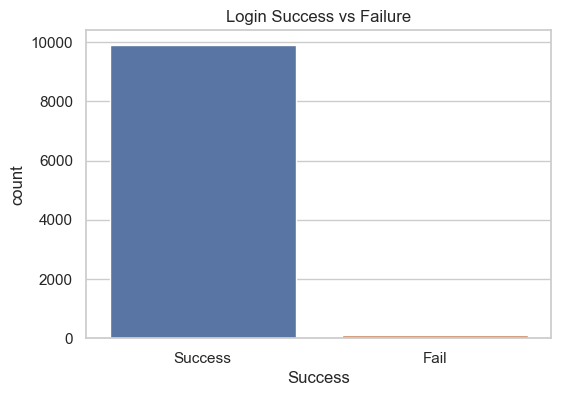

<Figure size 1000x600 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Sanity checks ---
print("\n--- Sanity Check ---")
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())

# --- 2. Basic behavioral stats ---
print("\n--- Basic Behavioral Stats ---")
print("Unique users:", df['User'].nunique())
print("Unique computers:", df['TargetComputer'].nunique())
print("\nSuccess vs Failure counts:\n", df['Success'].value_counts())
print("\nTop 5 AuthPackages:\n", df['AuthPackage'].value_counts().head())
print("\nTop 5 LogonTypes:\n", df['LogonType'].value_counts().head())

# --- 3. User-computer interaction matrix ---
user_computer_counts = df.groupby(['User', 'TargetComputer']).size().unstack(fill_value=0)
print("\nUser-Computer matrix snippet:\n", user_computer_counts.head())

# --- 4. Failed login streaks per user ---
fail_counts = df[df['Success'] == 'Failure'].groupby('User').size()
print("\nTop users by failure count:\n", fail_counts.sort_values(ascending=False).head(10))

# --- 5. Visualization: Success vs Failure ---
plt.figure(figsize=(6,4))
sns.countplot(x='Success', data=df)
plt.title("Login Success vs Failure")
plt.show()

# --- 6. Optional: Heatmap of user-computer logins ---
plt.figure(figsize=(10,6))
sample_uc_matrix = user_computer_counts.iloc


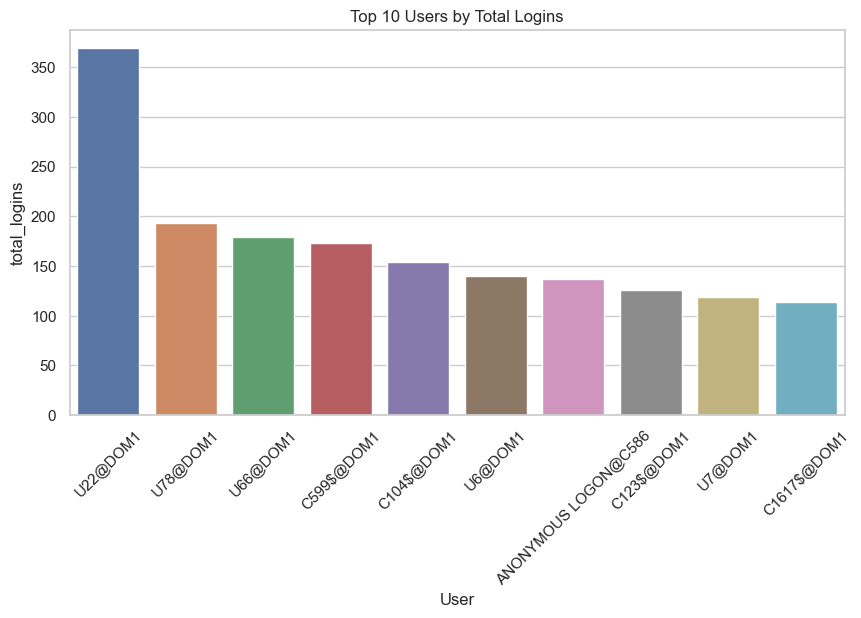

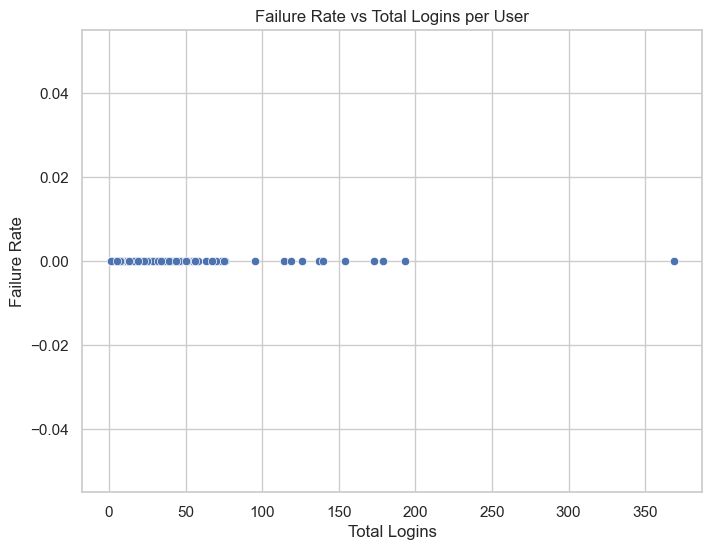

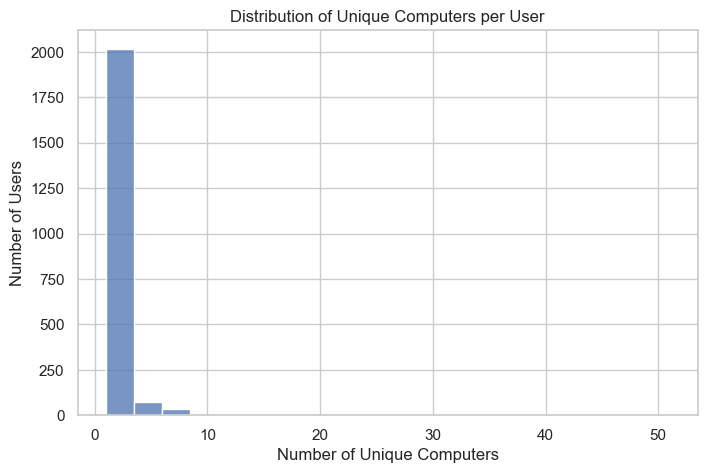

In [24]:
user_stats = df.groupby('User').agg(
    total_logins=('RecordID','count'),
    failed_logins=('Success', lambda x: (x=='Failure').sum()),
    unique_computers=('TargetComputer','nunique')
).reset_index()
user_stats['fail_rate'] = user_stats['failed_logins'] / user_stats['total_logins']

# --- 1. Bar chart of top 10 users by total logins ---
top10_users = user_stats.sort_values('total_logins', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='User', y='total_logins', data=top10_users)
plt.xticks(rotation=45)
plt.title("Top 10 Users by Total Logins")
plt.show()

# --- 2. Scatter plot: fail_rate vs total_logins ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='total_logins', y='fail_rate', data=user_stats)
plt.xlabel("Total Logins")
plt.ylabel("Failure Rate")
plt.title("Failure Rate vs Total Logins per User")
plt.show()

# --- 3. Histogram of unique computers per user ---
plt.figure(figsize=(8,5))
sns.histplot(user_stats['unique_computers'], bins=20, kde=False)
plt.xlabel("Number of Unique Computers")
plt.ylabel("Number of Users")
plt.title("Distribution of Unique Computers per User")
plt.show()

Users flagged by multiple models:
             User  total_logins  failed_logins  unique_computers  fail_rate  \
2100      U6@DOM1           140              0                18        0.0   
125   C1114$@DOM1            76              0                 8        0.0   
2118      U7@DOM1           119              0                 8        0.0   
634   C1766$@DOM1            73              0                 9        0.0   
621   C1734$@DOM1            28              0                 8        0.0   
2114     U78@DOM1           193              0                11        0.0   
1737   C832$@DOM1            39              0                 2        0.0   
1282  C3554$@DOM1            38              0                 2        0.0   
1122  C2796$@DOM1            28              0                 8        0.0   
1992    U175@DOM1            23              0                12        0.0   

      anomaly_score  is_anomaly  iso_anomaly  lof_anomaly  svm_anomaly  \
2100             -1   

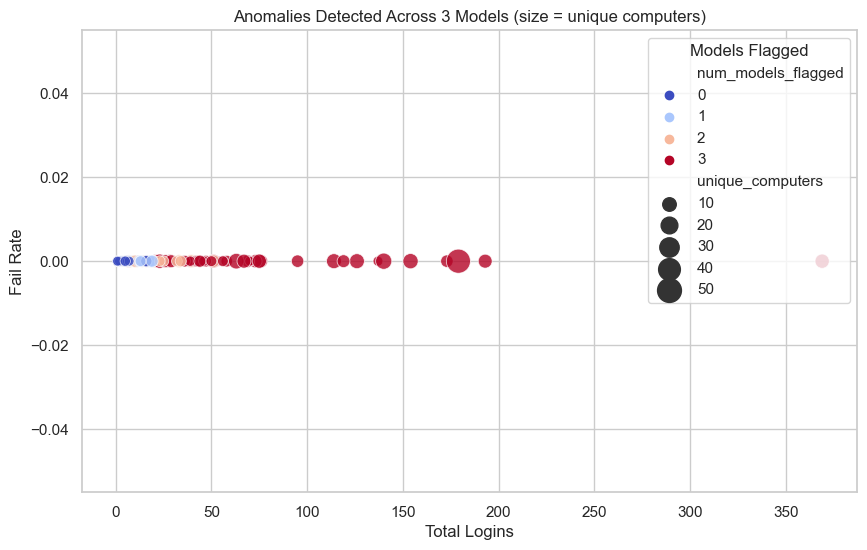


Anomaly table (first 20 rows):
             User  iso_anomaly  lof_anomaly  svm_anomaly  num_models_flagged
2100      U6@DOM1         True         True         True                   3
125   C1114$@DOM1         True         True         True                   3
2118      U7@DOM1         True         True         True                   3
634   C1766$@DOM1         True         True         True                   3
621   C1734$@DOM1         True         True         True                   3
2114     U78@DOM1         True         True         True                   3
1737   C832$@DOM1         True         True         True                   3
1282  C3554$@DOM1         True         True         True                   3
1122  C2796$@DOM1         True         True         True                   3
1992    U175@DOM1         True         True         True                   3
1422   C480$@DOM1         True         True         True                   3
2109     U75@DOM1         True         True 

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# --- 1. Prepare features ---
features = ['total_logins', 'failed_logins', 'unique_computers', 'fail_rate']
X = user_stats[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. Fit models ---
# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
user_stats['iso_anomaly'] = iso_forest.fit_predict(X_scaled) == -1

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
user_stats['lof_anomaly'] = lof.fit_predict(X_scaled) == -1

# One-Class SVM
oc_svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
user_stats['svm_anomaly'] = oc_svm.fit_predict(X_scaled) == -1

# --- 3. Count agreement ---
user_stats['num_models_flagged'] = user_stats[['iso_anomaly','lof_anomaly','svm_anomaly']].sum(axis=1)

print("Users flagged by multiple models:")
print(user_stats.sort_values('num_models_flagged', ascending=False).head(10))

# --- 4. Visualize model agreement ---
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='total_logins', 
    y='fail_rate', 
    hue='num_models_flagged', 
    palette='coolwarm', 
    size='unique_computers', 
    sizes=(50,300),
    alpha=0.8,
    data=user_stats
)
plt.xlabel("Total Logins")
plt.ylabel("Fail Rate")
plt.title("Anomalies Detected Across 3 Models (size = unique computers)")
plt.legend(title="Models Flagged")
plt.show()

# --- 5. Optional: show table of anomalies per model ---
anomaly_table = user_stats[['User','iso_anomaly','lof_anomaly','svm_anomaly','num_models_flagged']]
print("\nAnomaly table (first 20 rows):")
print(anomaly_table.sort_values('num_models_flagged', ascending=False).head(20))


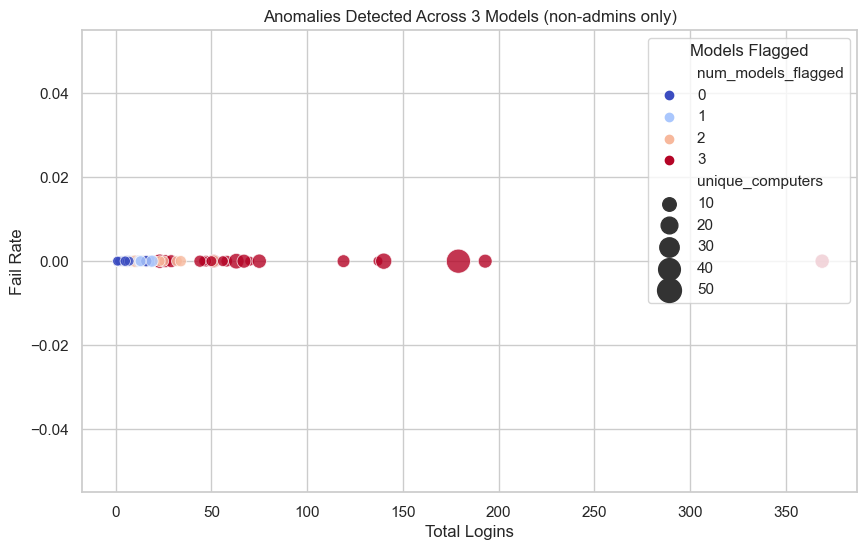


Anomaly table (non-admins only, first 20 rows):
                      User  iso_anomaly  lof_anomaly  svm_anomaly  \
1971              U14@DOM1         True         True         True   
1992             U175@DOM1         True         True         True   
2109              U75@DOM1         True         True         True   
2114              U78@DOM1         True         True         True   
2041             U292@DOM1         True         True         True   
2118               U7@DOM1         True         True         True   
2061               U3@DOM1         True         True         True   
2100               U6@DOM1         True         True         True   
1951            U1244@DOM1         True         True         True   
2095              U66@DOM1         True         True         True   
24    ANONYMOUS LOGON@C586         True         True         True   
1943             U113@DOM1         True         True         True   
22    ANONYMOUS LOGON@C529         True         True  

In [34]:
# --- 4. Visualize model agreement (exclude $ accounts) ---
non_admins = user_stats[~user_stats['User'].str.contains(r'\$', regex=True)]

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='total_logins', 
    y='fail_rate', 
    hue='num_models_flagged', 
    palette='coolwarm', 
    size='unique_computers', 
    sizes=(50,300),
    alpha=0.8,
    data=non_admins
)
plt.xlabel("Total Logins")
plt.ylabel("Fail Rate")
plt.title("Anomalies Detected Across 3 Models (non-admins only)")
plt.legend(title="Models Flagged")
plt.show()

# --- 5. Show table of anomalies per model (exclude $ accounts) ---
anomaly_table_non_admins = non_admins[['User','iso_anomaly','lof_anomaly','svm_anomaly','num_models_flagged']]
print("\nAnomaly table (non-admins only, first 20 rows):")
print(anomaly_table_non_admins.sort_values('num_models_flagged', ascending=False).head(20))


In [35]:
# Real Analysis: